# SPRM Dataset — Markov Analysis
Compares MFPT distributions and survival curves across SPRM datasets for a chosen parameter set.

In [5]:
%load_ext autoreload
%autoreload 2

import sys, json
from pathlib import Path
project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))

import numpy as np
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-darkgrid')
%matplotlib inline

MARKOV_OUTPUT = project_root / 'output' / 'markov_output'
# MARKOV_OUTPUT = project_root / 'cluster_output' / 'markov_output'


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Configuration
- `TARGET_PARAMS` — parameter values to match; only runs with all values equal are loaded.
- `TARGET_DATASETS` — which datasets to include in sections 2 & 3. Comment/uncomment entries to toggle. Set to `None` or `[]` to use all matched datasets.

> Section 4 (parameter grid) always loads every available dataset and run, ignoring both filters.

In [6]:
TARGET_PARAMS = dict(
    k_wrap        = 1.0,
    p_conc        = 100.0,
    cooperativity = 4.5,
    tau_max       = 1000.0,
    method        = 'ode',
)

# Datasets to include in sections 2 & 3.
# Set to None (or empty list) to use all datasets that match TARGET_PARAMS.
# TARGET_DATASETS = [
#     'ctrl01_random_genome_safe',
#     'ctrl02_random_genome_gcmatched',
#     'ctrl03_som_gcmatched',
#     # 'ctrl04_bound_prom_evicted',
#     # 'ctrl05_unbound_prom_random',
#     # 'ret_broad_nuc',
#     'ret_intermediate_nuc',
#     'ret_single_nuc',
# ]

TARGET_DATASETS = [
    'ret_all_stable147_refined',
]

## 1. Discover Matching Runs

In [7]:
def params_match(params_json: dict, target: dict) -> bool:
    """Check if a parameters.json dict matches all target values."""
    flat = {
        'k_wrap':        params_json.get('k_wrap'),
        'tau_max':       params_json.get('tau_max'),
        'method':        params_json.get('method'),
        'p_conc':        params_json.get('prot_params', {}).get('p_conc'),
        'cooperativity': params_json.get('prot_params', {}).get('cooperativity'),
    }
    return all(flat.get(k) == v for k, v in target.items())


matched = []
skipped = []

for ds_dir in sorted(MARKOV_OUTPUT.iterdir()):
    if not ds_dir.is_dir():
        continue
    # Filter by TARGET_DATASETS if specified
    if TARGET_DATASETS and ds_dir.name not in TARGET_DATASETS:
        continue
    for run_dir in sorted(ds_dir.iterdir()):
        if not run_dir.is_dir():
            continue
        pfile = run_dir / 'parameters.json'
        if not pfile.exists():
            continue
        p = json.loads(pfile.read_text())
        if params_match(p, TARGET_PARAMS):
            matched.append({'dataset': ds_dir.name, 'run_dir': run_dir, 'params': p})
        else:
            skipped.append(ds_dir.name)

print(f'Matched {len(matched)} dataset(s):')
for m in matched:
    print(f'  ✓  {m["dataset"]}  →  {m["run_dir"].name}')
if skipped:
    print(f'\nSkipped (different params): {skipped}')

Matched 1 dataset(s):
  ✓  ret_all_stable147_refined  →  k1.0_p100.0_c4.5_tau1000_ode__91f865


## 2. MFPT Distributions

In [8]:
frames = []
for m in matched:
    for f in (m['run_dir'] / 'summaries').glob('*.tsv'):
        df = pd.read_csv(f, sep='\t')
        df['dataset'] = m['dataset']
        frames.append(df)

mfpt_df = pd.concat(frames, ignore_index=True)
mfpt_df['mfpt'] = pd.to_numeric(mfpt_df['mfpt'], errors='coerce')
mfpt_df['log10_mfpt'] = np.where(
    np.isfinite(mfpt_df['mfpt']) & (mfpt_df['mfpt'] > 0),
    np.log10(mfpt_df['mfpt']), np.nan
)

datasets = [m['dataset'] for m in matched]
palette  = dict(zip(datasets, sns.color_palette('tab10', len(datasets))))
valid    = mfpt_df[np.isfinite(mfpt_df['log10_mfpt'])]

# Quick stats
stats = (mfpt_df.groupby('dataset')
         .agg(n_total=('mfpt','size'),
              n_finite=('mfpt', lambda x: np.isfinite(x).sum()),
              pct_censored=('mfpt', lambda x: 100*(~np.isfinite(x)).mean()),
              mfpt_median=('mfpt', lambda x: x[np.isfinite(x)].median()),
              log10_median=('log10_mfpt','median'))
         .reindex(datasets))
display(stats)

,n_total,n_finite,pct_censored,mfpt_median,log10_median
dataset,,,,,
ret_all_stable147_refined,100,100,0.0,28332.131685,4.452276


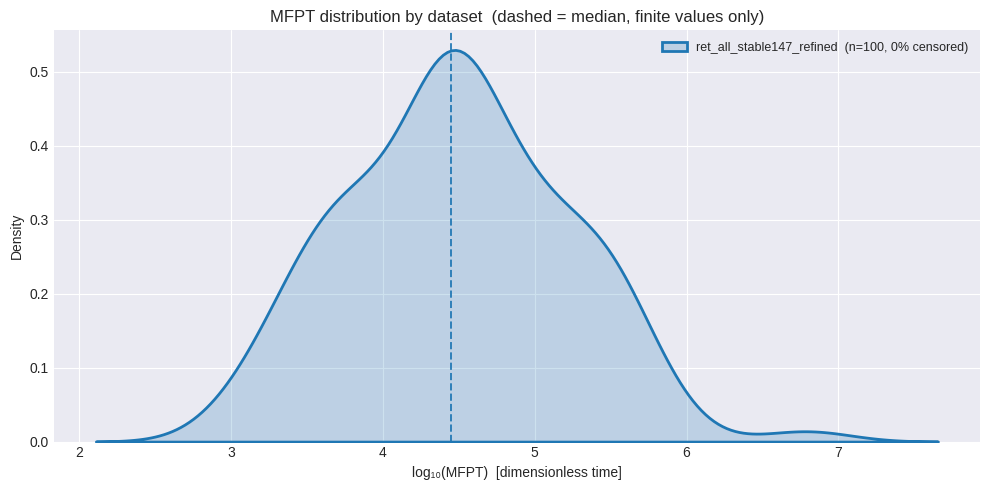

In [9]:
# Overlaid KDE
fig, ax = plt.subplots(figsize=(10, 5))
for ds in datasets:
    sub = valid[valid['dataset'] == ds]['log10_mfpt'].dropna()
    if sub.empty:
        continue
    row = stats.loc[ds]
    label = f"{ds}  (n={int(row['n_finite'])}, {row['pct_censored']:.0f}% censored)"
    sns.kdeplot(sub, ax=ax, label=label, color=palette[ds], fill=True, alpha=0.22, linewidth=2)
    ax.axvline(row['log10_median'], color=palette[ds], ls='--', lw=1.4, alpha=0.9)

ax.set_xlabel('log₁₀(MFPT)  [dimensionless time]')
ax.set_ylabel('Density')
ax.set_title('MFPT distribution by dataset  (dashed = median, finite values only)')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

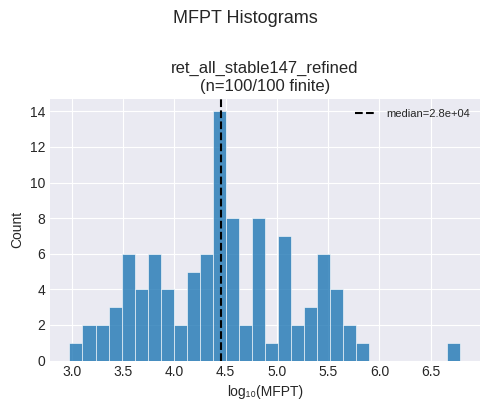

In [10]:
# Per-dataset histograms
ncols = min(3, len(datasets))
nrows = int(np.ceil(len(datasets) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 4*nrows), squeeze=False)
axes_flat = axes.ravel()

for idx, ds in enumerate(datasets):
    ax = axes_flat[idx]
    sub = valid[valid['dataset'] == ds]['log10_mfpt'].dropna()
    row = stats.loc[ds]
    ax.hist(sub, bins=30, color=palette[ds], alpha=0.8, edgecolor='white', linewidth=0.5)
    ax.axvline(row['log10_median'], color='k', ls='--', lw=1.5,
               label=f"median={row['mfpt_median']:.1e}")
    ax.set_title(f"{ds}\n(n={int(row['n_finite'])}/{int(row['n_total'])} finite)")
    ax.set_xlabel('log₁₀(MFPT)')
    ax.set_ylabel('Count')
    ax.legend(fontsize=8)

for ax in axes_flat[len(datasets):]:
    ax.set_visible(False)
plt.suptitle('MFPT Histograms', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## 3. Survival Curves

In [11]:
survival_data = {}
for m in matched:
    surv_files = list((m['run_dir'] / 'survivals').glob('*.parquet'))
    if not surv_files:
        print(f'  skip {m["dataset"]}: no survival files')
        continue
    df = pl.concat([pl.read_parquet(f) for f in surv_files])
    tau = np.asarray(df.row(0, named=True)['tau_grid'])
    S   = np.array(df['survival'].to_list(), dtype=float)  # (n_nucs, n_t)
    survival_data[m['dataset']] = {
        'tau': tau, 'S': S,
        'mean': np.nanmean(S, axis=0),
        'std':  np.nanstd(S,  axis=0),
    }
    print(f'  ✓  {m["dataset"]}: {S.shape[0]} nucleosomes')

ds_surv = [ds for ds in datasets if ds in survival_data]

  ✓  ret_all_stable147_refined: 100 nucleosomes


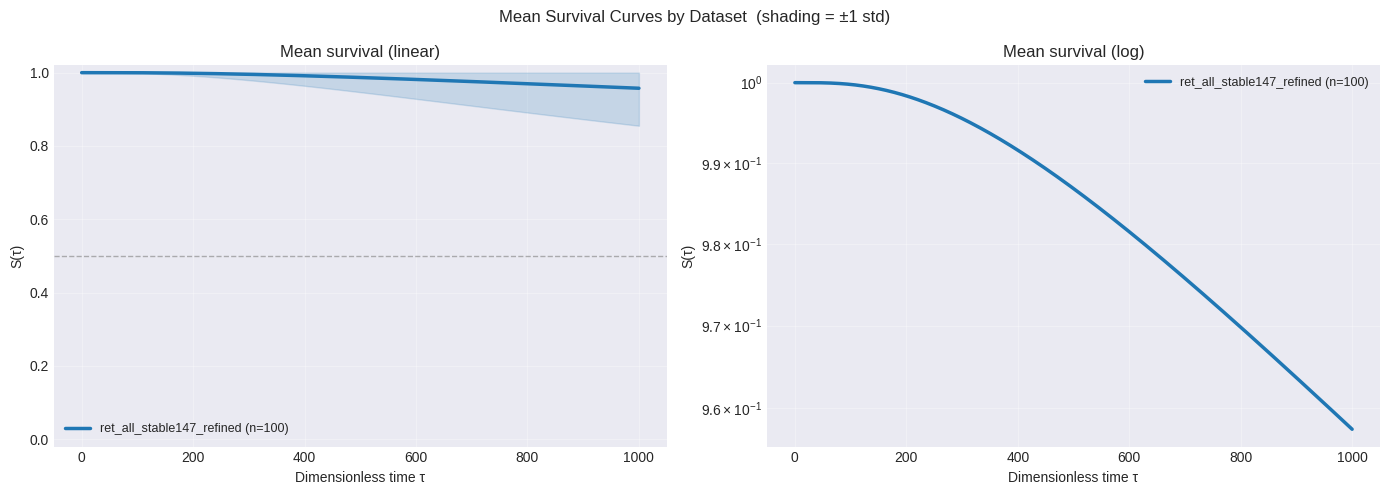

In [12]:
# Overlaid mean survival — linear and log
fig, (ax_lin, ax_log) = plt.subplots(1, 2, figsize=(14, 5))

for ds in ds_surv:
    d = survival_data[ds]
    t, m, s = d['tau'], d['mean'], d['std']
    c = palette[ds]
    n = d['S'].shape[0]
    ax_lin.plot(t, m, lw=2.5, color=c, label=f"{ds} (n={n})")
    ax_lin.fill_between(t, np.clip(m-s,0,1), np.clip(m+s,0,1), color=c, alpha=0.18)
    ax_log.semilogy(t, m + 1e-12, lw=2.5, color=c, label=f"{ds} (n={n})")

ax_lin.axhline(0.5, color='gray', ls='--', lw=1, alpha=0.6)
for ax, title in zip([ax_lin, ax_log], ['Mean survival (linear)', 'Mean survival (log)']):
    ax.set_xlabel('Dimensionless time τ')
    ax.set_ylabel('S(τ)')
    ax.set_title(title)
    ax.legend(fontsize=9)
    ax.grid(True, which='both', alpha=0.3)
ax_lin.set_ylim(-0.02, 1.02)

plt.suptitle('Mean Survival Curves by Dataset  (shading = ±1 std)', fontsize=12)
plt.tight_layout()
plt.show()

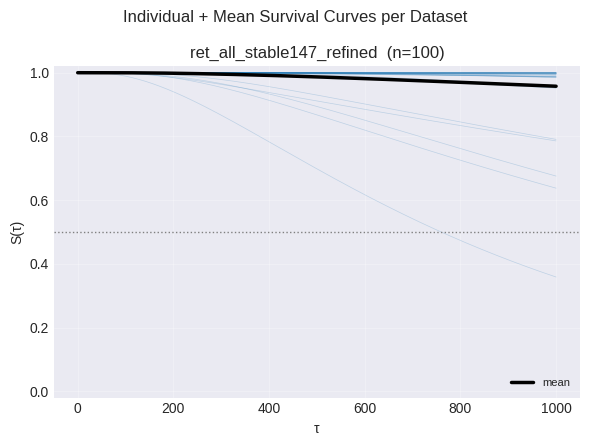

In [13]:
# Per-dataset panels: sampled individual traces + mean
MAX_TRACES = 30
rng = np.random.default_rng(42)

ncols = min(3, len(ds_surv))
nrows = int(np.ceil(len(ds_surv) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(6*ncols, 4.5*nrows), squeeze=False)
axes_flat = axes.ravel()

for idx, ds in enumerate(ds_surv):
    ax = axes_flat[idx]
    d  = survival_data[ds]
    sample_idx = rng.choice(d['S'].shape[0], size=min(MAX_TRACES, d['S'].shape[0]), replace=False)
    for i in sample_idx:
        ax.plot(d['tau'], d['S'][i], lw=0.5, alpha=0.22, color=palette[ds])
    ax.plot(d['tau'], d['mean'],   lw=2.5, color='black', label='mean')
    ax.plot(d['tau'], d['std'],    lw=0)   # invisible, just for spacing
    ax.axhline(0.5, color='gray', ls=':', lw=1)
    ax.set_title(f"{ds}  (n={d['S'].shape[0]})")
    ax.set_xlabel('τ')
    ax.set_ylabel('S(τ)')
    ax.set_ylim(-0.02, 1.02)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.25)

for ax in axes_flat[len(ds_surv):]:
    ax.set_visible(False)

plt.suptitle('Individual + Mean Survival Curves per Dataset', fontsize=12)
plt.tight_layout()
plt.show()

## 4. Parameter Grid Analysis
Loads **all** available `(p_conc, cooperativity)` runs across every dataset and compares them.

- **Heatmaps** — median MFPT over the full 2D parameter space, one panel per dataset
- **Dose-response lines** — median MFPT vs p_conc, one line per cooperativity value, one panel per dataset
- **Cross-dataset comparison** — at a chosen (p_conc, coop) point, which biological condition differs?

In [64]:
# ── Discover ALL (dataset, p_conc, cooperativity) runs ───────────────────────
grid_records = []

for ds_dir in sorted(MARKOV_OUTPUT.iterdir()):
    if not ds_dir.is_dir():
        continue
    for run_dir in sorted(ds_dir.iterdir()):
        if not run_dir.is_dir():
            continue
        pfile = run_dir / 'parameters.json'
        if not pfile.exists():
            continue
        p = json.loads(pfile.read_text())
        tsv_files = list((run_dir / 'summaries').glob('*.tsv'))
        if not tsv_files:
            continue
        grid_records.append({
            'dataset':       ds_dir.name,
            'run_dir':       run_dir,
            'p_conc':        p.get('prot_params', {}).get('p_conc', float('nan')),
            'cooperativity': p.get('prot_params', {}).get('cooperativity', float('nan')),
            'k_wrap':        p.get('k_wrap', 1.0),
            'tau_max':       p.get('tau_max', 1000.0),
            'method':        p.get('method', 'ode'),
        })

grid_meta = pd.DataFrame(grid_records)
print(f'Found {len(grid_meta)} completed runs across {grid_meta["dataset"].nunique()} dataset(s)')
print(f'p_conc values      : {sorted(grid_meta["p_conc"].unique())}')
print(f'cooperativity values: {sorted(grid_meta["cooperativity"].unique())}')
display(grid_meta.drop(columns='run_dir').sort_values(['dataset','p_conc','cooperativity']))

Found 368 completed runs across 8 dataset(s)
p_conc values      : [np.float64(0.0), np.float64(0.001), np.float64(0.01), np.float64(1.0), np.float64(10.0), np.float64(50.0), np.float64(100.0), np.float64(200.0), np.float64(500.0), np.float64(1000.0)]
cooperativity values: [np.float64(0.0), np.float64(2.0), np.float64(4.0), np.float64(4.5), np.float64(5.0)]


,dataset,p_conc,cooperativity,k_wrap,tau_max,method
2,ctrl01_random_genome_safe,0.000,0.0,1.0,10000.0,ode
1,ctrl01_random_genome_safe,0.001,0.0,1.0,10000.0,ode
3,ctrl01_random_genome_safe,0.001,2.0,1.0,10000.0,ode
6,ctrl01_random_genome_safe,0.001,4.0,1.0,10000.0,ode
7,ctrl01_random_genome_safe,0.001,4.5,1.0,10000.0,ode
...,...,...,...,...,...,...
348,ret_single_nuc,1000.000,0.0,1.0,10000.0,ode
349,ret_single_nuc,1000.000,2.0,1.0,10000.0,ode
350,ret_single_nuc,1000.000,4.0,1.0,10000.0,ode
351,ret_single_nuc,1000.000,4.5,1.0,10000.0,ode


In [65]:
# ── Load MFPT summaries for all runs in the grid ─────────────────────────────
grid_frames = []
for _, row in grid_meta.iterrows():
    for f in (row['run_dir'] / 'summaries').glob('*.tsv'):
        df = pd.read_csv(f, sep='\t')
        df['dataset']       = row['dataset']
        df['p_conc']        = row['p_conc']
        df['cooperativity'] = row['cooperativity']
        grid_frames.append(df)

grid_df = pd.concat(grid_frames, ignore_index=True)
grid_df['mfpt'] = pd.to_numeric(grid_df['mfpt'], errors='coerce')

# Per-run statistics — explicit aggregation avoids pandas version issues with apply()
def _finite_median(x):
    f = x[np.isfinite(x)]; return f.median() if len(f) else np.nan
def _finite_mean(x):
    f = x[np.isfinite(x)]; return f.mean() if len(f) else np.nan
def _pct_censored(x):
    return 100 * (~np.isfinite(x)).mean()
def _n_finite(x):
    return int(np.isfinite(x).sum())

grid_stats = (
    grid_df.groupby(['dataset', 'p_conc', 'cooperativity'])['mfpt']
    .agg(mfpt_median=_finite_median,
         mfpt_mean=_finite_mean,
         pct_censored=_pct_censored,
         n_finite=_n_finite)
    .reset_index()
)
grid_stats['log10_median'] = np.where(
    np.isfinite(grid_stats['mfpt_median']) & (grid_stats['mfpt_median'] > 0),
    np.log10(grid_stats['mfpt_median']), np.nan
)

print(f'Grid summary: {len(grid_stats)} (dataset, p_conc, coop) combinations')
display(grid_stats.head(8))

Grid summary: 368 (dataset, p_conc, coop) combinations


,dataset,p_conc,cooperativity,mfpt_median,mfpt_mean,pct_censored,n_finite,log10_median
0,ctrl01_random_genome_safe,0.000,0.0,650.193312,1.057600e+07,3.600,19280,2.813042
1,ctrl01_random_genome_safe,0.001,0.0,650.180366,1.057459e+07,3.600,19280,2.813034
2,ctrl01_random_genome_safe,0.001,2.0,650.180365,1.057459e+07,3.600,19280,2.813034
3,ctrl01_random_genome_safe,0.001,4.0,650.180361,1.057459e+07,3.600,19280,2.813034
4,ctrl01_random_genome_safe,0.001,4.5,650.180358,1.057459e+07,3.600,19280,2.813034
5,ctrl01_random_genome_safe,0.001,5.0,650.180353,1.057459e+07,3.600,19280,2.813034
6,ctrl01_random_genome_safe,0.010,0.0,650.104169,1.065330e+07,3.595,19281,2.812983
7,ctrl01_random_genome_safe,0.010,2.0,650.104143,1.065330e+07,3.595,19281,2.812983


### 4a. Heatmaps — median MFPT over the 2D parameter space
One panel per dataset. Color = log₁₀(median MFPT).

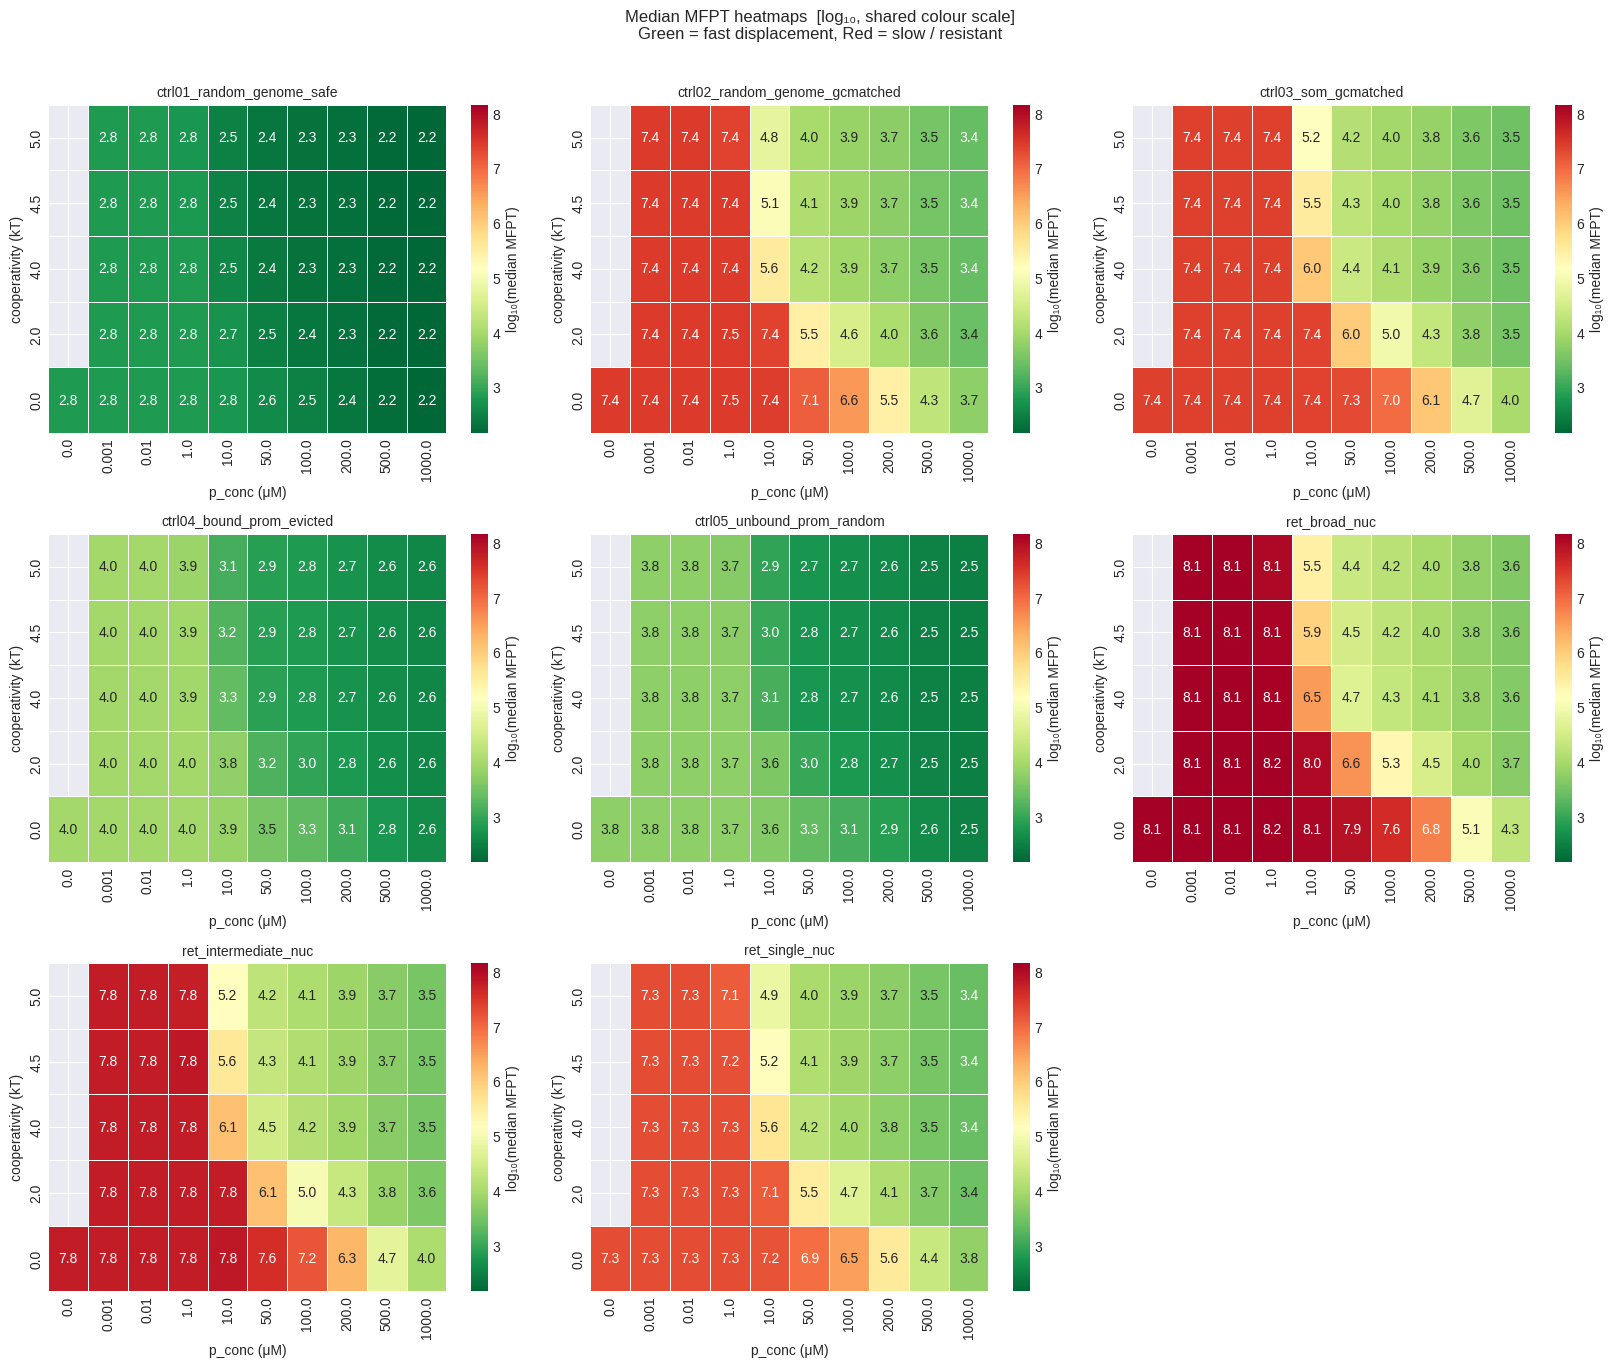

In [66]:
all_datasets  = sorted(grid_stats['dataset'].unique())
p_conc_vals   = sorted(grid_stats['p_conc'].unique())
coop_vals     = sorted(grid_stats['cooperativity'].unique())

ncols = min(3, len(all_datasets))
nrows = int(np.ceil(len(all_datasets) / ncols))

# Shared colour scale across all datasets for comparability
vmin = grid_stats['log10_median'].min()
vmax = grid_stats['log10_median'].max()

fig, axes = plt.subplots(nrows, ncols, figsize=(5.5*ncols, 4.5*nrows), squeeze=False)
axes_flat = axes.ravel()

for idx, ds in enumerate(all_datasets):
    ax = axes_flat[idx]
    sub = grid_stats[grid_stats['dataset'] == ds]

    # Pivot to (coop rows) × (p_conc cols)
    pivot = (sub.pivot(index='cooperativity', columns='p_conc', values='log10_median')
               .reindex(index=coop_vals[::-1], columns=p_conc_vals))  # high coop at top

    sns.heatmap(pivot, ax=ax, cmap='RdYlGn_r',
                vmin=vmin, vmax=vmax,
                annot=True, fmt='.1f', linewidths=0.5,
                cbar_kws={'label': 'log₁₀(median MFPT)'})
    ax.set_title(ds, fontsize=10)
    ax.set_xlabel('p_conc (μM)')
    ax.set_ylabel('cooperativity (kT)')

for ax in axes_flat[len(all_datasets):]:
    ax.set_visible(False)

plt.suptitle('Median MFPT heatmaps  [log₁₀, shared colour scale]\n'
             'Green = fast displacement, Red = slow / resistant', fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

### 4b. Dose-response curves — median MFPT vs p_conc
One panel per dataset. Each line is a cooperativity value.

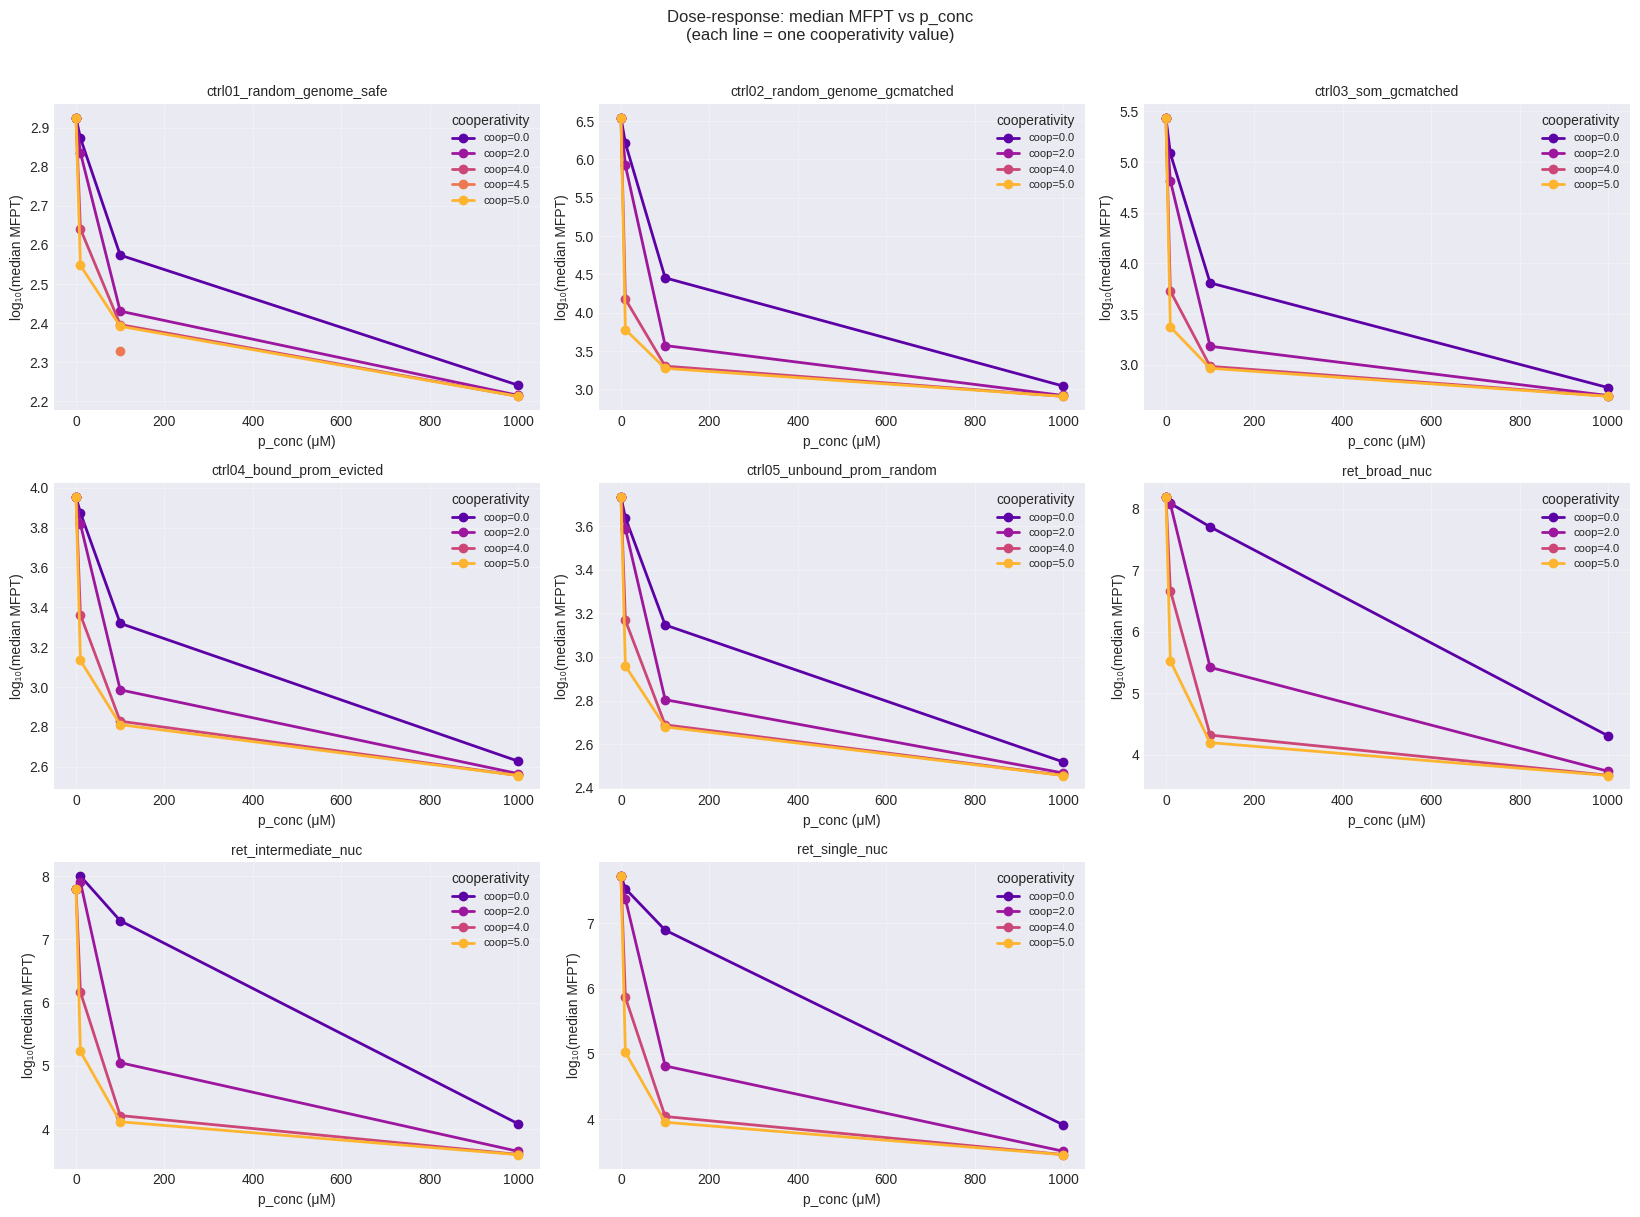

In [17]:
coop_palette = dict(zip(coop_vals, sns.color_palette('plasma', len(coop_vals))))

fig, axes = plt.subplots(nrows, ncols, figsize=(5.5*ncols, 4*nrows),
                         squeeze=False, sharey=False)
axes_flat = axes.ravel()

for idx, ds in enumerate(all_datasets):
    ax = axes_flat[idx]
    sub = grid_stats[grid_stats['dataset'] == ds].sort_values('p_conc')
    for coop in coop_vals:
        line = sub[sub['cooperativity'] == coop]
        if line.empty:
            continue
        ax.plot(line['p_conc'], line['log10_median'],
                marker='o', lw=2, ms=6,
                color=coop_palette[coop],
                label=f'coop={coop}')
    ax.set_title(ds, fontsize=10)
    ax.set_xlabel('p_conc (\u03bcM)')
    ax.set_ylabel('log\u2081\u2080(median MFPT)')
    ax.legend(fontsize=8, title='cooperativity')
    ax.grid(True, alpha=0.3)

for ax in axes_flat[len(all_datasets):]:
    ax.set_visible(False)

plt.suptitle('Dose-response: median MFPT vs p_conc\n(each line = one cooperativity value)',
             fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

### 4c. Cross-dataset comparison — fixed (p_conc, cooperativity)
Choose a reference parameter point and compare median MFPT across all datasets.

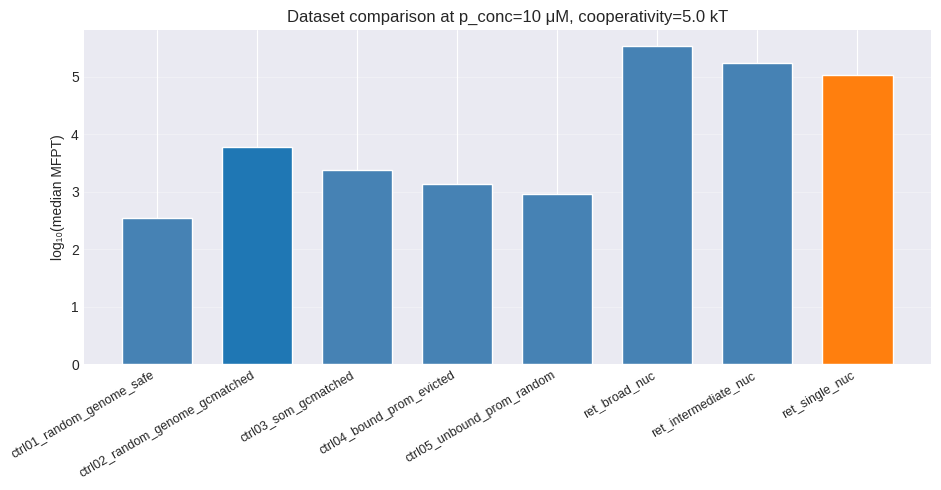

,median MFPT,log10(median),% censored,n finite
dataset,,,,
ctrl01_random_genome_safe,352.936575,2.547697,0.00,2000
ctrl02_random_genome_gcmatched,6039.895727,3.781029,0.00,2000
ctrl03_som_gcmatched,2365.013778,3.373834,0.00,2000
ctrl04_bound_prom_evicted,1360.510569,3.133702,0.00,2000
ctrl05_unbound_prom_random,910.077377,2.959078,0.00,2000
ret_broad_nuc,335231.270987,5.525345,0.30,1994
ret_intermediate_nuc,168844.047154,5.227486,0.25,1995
ret_single_nuc,105957.563467,5.025132,0.30,1994


In [18]:
# ── Choose which (p_conc, coop) point to compare datasets at ─────────────────
COMPARE_P_CONC = 10     # change to any value in p_conc_vals
COMPARE_COOP   = 5.0         # change to any value in coop_vals

sub = grid_stats[
    (grid_stats['p_conc']        == COMPARE_P_CONC) &
    (grid_stats['cooperativity'] == COMPARE_COOP)
].set_index('dataset').reindex(all_datasets)

fig, ax = plt.subplots(figsize=(max(6, 1.2*len(all_datasets)), 5))
colors_bar = [palette.get(ds, 'steelblue') for ds in all_datasets]
ax.bar(range(len(all_datasets)), sub['log10_median'], color=colors_bar,
       edgecolor='white', width=0.7)
ax.set_xticks(range(len(all_datasets)))
ax.set_xticklabels(all_datasets, rotation=30, ha='right', fontsize=9)
ax.set_ylabel('log\u2081\u2080(median MFPT)')
ax.set_title(f'Dataset comparison at p_conc={COMPARE_P_CONC} \u03bcM, cooperativity={COMPARE_COOP} kT')
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Also print the table
display(sub[['mfpt_median','log10_median','pct_censored','n_finite']].rename(columns={
    'mfpt_median':  'median MFPT',
    'log10_median': 'log10(median)',
    'pct_censored': '% censored',
    'n_finite':     'n finite',
}))